EfficientNet refers to a family of CNN models (B0–B7) that you use for image classification, but these models were not designed manually—they were created using a smart compound scaling algorithm. This algorithm determines how to expand a model’s width, depth, and input resolution in a balanced and efficient way, so accuracy improves without wasting computation. The algorithm is used only during architecture design, while the thing you actually use is the pretrained EfficientNet model, loaded through TensorFlow (e.g., tf.keras.applications.EfficientNetB0(...)) for prediction and transfer learning.

In [ ]:
!git clone -b EfficientNetB3_Peng https://github.com/seanmcgowanx/coral-reef-classification.git

Cloning into 'coral-reef-classification'...
remote: Enumerating objects: 93, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 93 (delta 15), reused 23 (delta 5), pack-reused 47 (from 1)
Receiving objects: 100% (93/93), 63.13 MiB | 12.26 MiB/s, done.
Resolving deltas: 100% (20/20), done.


In [1]:
!rm -rf /content/drive #complete clean up and remount only when remount not successful


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [2]:
!git clone https://github.com/seanmcgowanx/coral-reef-classification.git


Cloning into 'coral-reef-classification'...
remote: Enumerating objects: 143, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (88/88), done.
remote: Total 143 (delta 38), reused 21 (delta 4), pack-reused 47 (from 1)
Receiving objects: 100% (143/143), 65.31 MiB | 17.03 MiB/s, done.
Resolving deltas: 100% (43/43), done.


In [3]:
# Import Configuration
import sys      # sys lets us modify the Python import path (sys.path)
import os       # os gives access to environment variables, paths, and directory operations

def in_colab():
    # Detect whether the code is running inside Google Colab.
    # Colab sets "COLAB_GPU" in environment variables OR loads "google.colab" module.
    return "COLAB_GPU" in os.environ or "google.colab" in sys.modules

if in_colab():
    # If running in Google Colab:
    # Set the repository path to where GitHub repos are usually cloned in Colab.
    repo_path = "/content/coral-reef-classification"

    # Set the dataset path under the repo (processed data folder).
    data_path = "/content/coral-reef-classification/data/processed"
else:
    # If running on your local machine (e.g., VS Code):

    # repo_path = parent folder of the current working directory
    # os.getcwd() gives the current directory
    # os.path.join(..., "..") moves one folder upward
    # os.path.abspath cleans and converts to full absolute path
    repo_path = os.path.abspath(os.path.join(os.getcwd(), ".."))

    # data_path = parent folder → data → processed
    data_path = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "processed"))

# Add repo_path to the Python module search path if it's not already included.
# This allows importing Python modules from the cloned repository.
if repo_path not in sys.path:
    sys.path.append(repo_path)

# Print the paths being used so the user can verify correctness.
print("Using repo path:", repo_path)
print("Using data path:", data_path)


Using repo path: /content/coral-reef-classification
Using data path: /content/coral-reef-classification/data/processed


In [4]:
# =====================================================================
# FINAL PIPELINE — EfficientNetB3 Multi-Label Classifier
# Direct Image Loading from MERMAID S3 Bucket
# =====================================================================

import os
import sys
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

# =====================================================================
# 1. LOAD REPO CSVs (multi-hot labels)
# =====================================================================

def in_colab():
    return "COLAB_GPU" in os.environ or "google.colab" in sys.modules

if in_colab():
    repo_path = "/content/coral-reef-classification"
    data_path = "/content/coral-reef-classification/data/processed"
else:
    repo_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
    data_path = os.path.abspath(os.path.join(repo_path, "data", "processed"))

train_csv = os.path.join(data_path, "final_labels_train.csv")
test_csv  = os.path.join(data_path, "final_labels_test.csv")

df_train_full = pd.read_csv(train_csv)
df_test       = pd.read_csv(test_csv)

NON_CLASS_COLS = ["image_id", "region_id", "region_name"]
CLASSES = [c for c in df_train_full.columns if c not in NON_CLASS_COLS]

print("Classes:", CLASSES)


# =====================================================================
# 2. STRATIFIED TRAIN / VAL SPLIT (10%)
# =====================================================================

df_train_full["region_name"] = df_train_full["region_name"].astype(str)

train_df, val_df = train_test_split(
    df_train_full,
    test_size=0.05,
    shuffle=True,
    random_state=42,
    stratify=df_train_full["region_name"]
)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(df_test))


# =====================================================================
# 3. BUILD S3 IMAGE PATHS
# =====================================================================

def add_s3_path(df):
    df["filepath"] = df["image_id"].apply(
        lambda x: f"s3://coral-reef-training/mermaid/{x}.png"
    )
    return df

train_df = add_s3_path(train_df)
val_df   = add_s3_path(val_df)
df_test  = add_s3_path(df_test)


# =====================================================================
# 4. CONVERT TO NUMPY (X paths and y labels)
# =====================================================================

def df_to_Xy(df):
    NON_CLASS_COLS = ["image_id", "filepath", "region_id", "region_name"]
    class_cols = [c for c in df.columns if c not in NON_CLASS_COLS]

    X = df["filepath"].values
    y = df[class_cols].values.astype("float32")

    return X, y, class_cols


X_train, y_train, CLASSES = df_to_Xy(train_df)
X_val,   y_val, _         = df_to_Xy(val_df)
X_test,  y_test, _        = df_to_Xy(df_test)

NUM_CLASSES = len(CLASSES)
print("NUM_CLASSES =", NUM_CLASSES)


# =====================================================================
# 5. S3 IMAGE LOADER via boto3 + tf.numpy_function
# =====================================================================
!pip install boto3 botocore


import boto3
from botocore.config import Config
from botocore import UNSIGNED
import io
from PIL import Image

s3_client = boto3.client(
    "s3",
    region_name="us-east-1",
    config=Config(signature_version=UNSIGNED)
)

PATCH_SIZE = 300

def load_image_from_s3(path):
    """Loads one MERMAID image from S3 and returns preprocesssed numpy array."""
    path = path.decode()
    image_id = path.split("/")[-1].replace(".png", "")
    key = f"mermaid/{image_id}.png"

    resp = s3_client.get_object(Bucket="coral-reef-training", Key=key)
    img = Image.open(io.BytesIO(resp["Body"].read())).convert("RGB")
    img = img.resize((PATCH_SIZE, PATCH_SIZE))

    img = np.array(img).astype("float32")
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img


def load_image(path, label):
    img = tf.numpy_function(load_image_from_s3, [path], tf.float32)
    img = tf.reshape(img, (PATCH_SIZE, PATCH_SIZE, 3))
    return img, label


# =====================================================================
# 6. MULTI-LABEL OVERSAMPLING (balanced)
# =====================================================================

class_counts = y_train.sum(axis=0)
freq = class_counts / len(y_train)
class_weights = 1.0 / (freq + 1e-6)
class_weights = class_weights / class_weights.sum()

sample_weights = (y_train * class_weights).sum(axis=1)
sample_weights = sample_weights / sample_weights.sum()

def sample_indices(n_samples):
    return np.random.choice(
        np.arange(len(X_train)),
        size=n_samples,
        replace=True,
        p=sample_weights
    )

def make_oversample_ds(X, y, batch_size):
    def gen():
        while True:
            idx = sample_indices(batch_size)
            yield X[idx], y[idx]

    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=(None,), dtype=tf.string),
            tf.TensorSpec(shape=(None, NUM_CLASSES), dtype=tf.float32),
        )
    )

    ds = ds.unbatch()
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


BATCH_SIZE = 32
train_ds = make_oversample_ds(X_train, y_train, BATCH_SIZE)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
      .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
      .batch(BATCH_SIZE)
      .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
      .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
      .batch(BATCH_SIZE)
      .prefetch(tf.data.AUTOTUNE)
)


Classes: ['Macroalgae', 'Rubble', 'Crustose coralline algae', 'Bare substrate', 'Sand', 'Turf algae', 'Porites', 'Hard coral', 'Soft coral', 'Acropora', 'Tape', 'Pocillopora', 'Dead coral', 'Montipora', 'Cyanobacteria', 'Sponge']
Train: 2503 Val: 132 Test: 2186
NUM_CLASSES = 16
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 144.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 7.7 MB/s eta 0:00:00


10 images WITHIN the repo 4821 that have 0 valid labels
16950ff1-7d4a-4275-8cc9-a10ee06445dc
3a375b2b-e872-4912-93d8-5182ba2de301
41ea9502-fb0f-471d-bc30-28593cdcdf94
4b5a4809-857d-47a7-a014-547322ec48cd
6cb09bb9-4865-4569-9d8e-f6bd712cd20d
710bd5ce-ff83-48b6-b3e7-6cb628d4ef93
83f648e8-565c-4290-98eb-738a23752d54
8b45642e-bebc-41a5-811f-04b4aa9b1d44
8f4e330c-1f2f-4bb5-95ee-647fbfa0c2aa
c8a32fed-edb4-41aa-be34-eed659870643


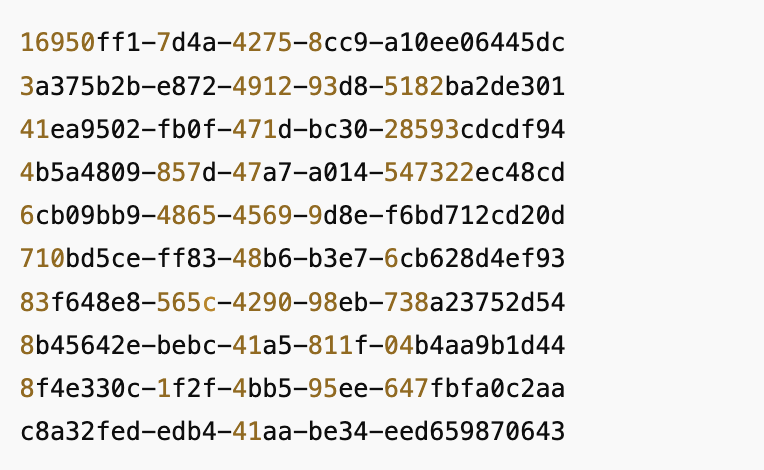

In [7]:
# =====================================================================
# 7. EfficientNetB3 MODEL
# =====================================================================

base = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    pooling="avg",
    input_shape=(PATCH_SIZE, PATCH_SIZE, 3)
)

base.trainable = False

inputs = layers.Input((PATCH_SIZE, PATCH_SIZE, 3))
x = base(inputs)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="AUC", multi_label=True)]
)

model.summary()


# =====================================================================
# 8. CALLBACKS
# =====================================================================

CHECKPOINT_DIR = "/content/drive/My Drive/AAI-501-02/Final_project/effnet_multi_label_ckpt_B3_repo_oversample_v5_Dave_S3_PullIMGs"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

stage1_ckpt = f"{CHECKPOINT_DIR}/best_stage1.keras"
stage2_ckpt = f"{CHECKPOINT_DIR}/best_stage2.keras"

check1 = tf.keras.callbacks.ModelCheckpoint(
    stage1_ckpt, monitor="val_AUC", mode="max", save_best_only=True
)

check2 = tf.keras.callbacks.ModelCheckpoint(
    stage2_ckpt, monitor="val_AUC", save_best_only=True, mode="max")

early = tf.keras.callbacks.EarlyStopping(
    monitor="val_AUC", mode="max",
    patience=7, min_delta=0.001,
    restore_best_weights=True
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 1536)           │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │        24,592 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,808,127 (41.23 MB)

 Trainable params: 24,592 (96.06 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

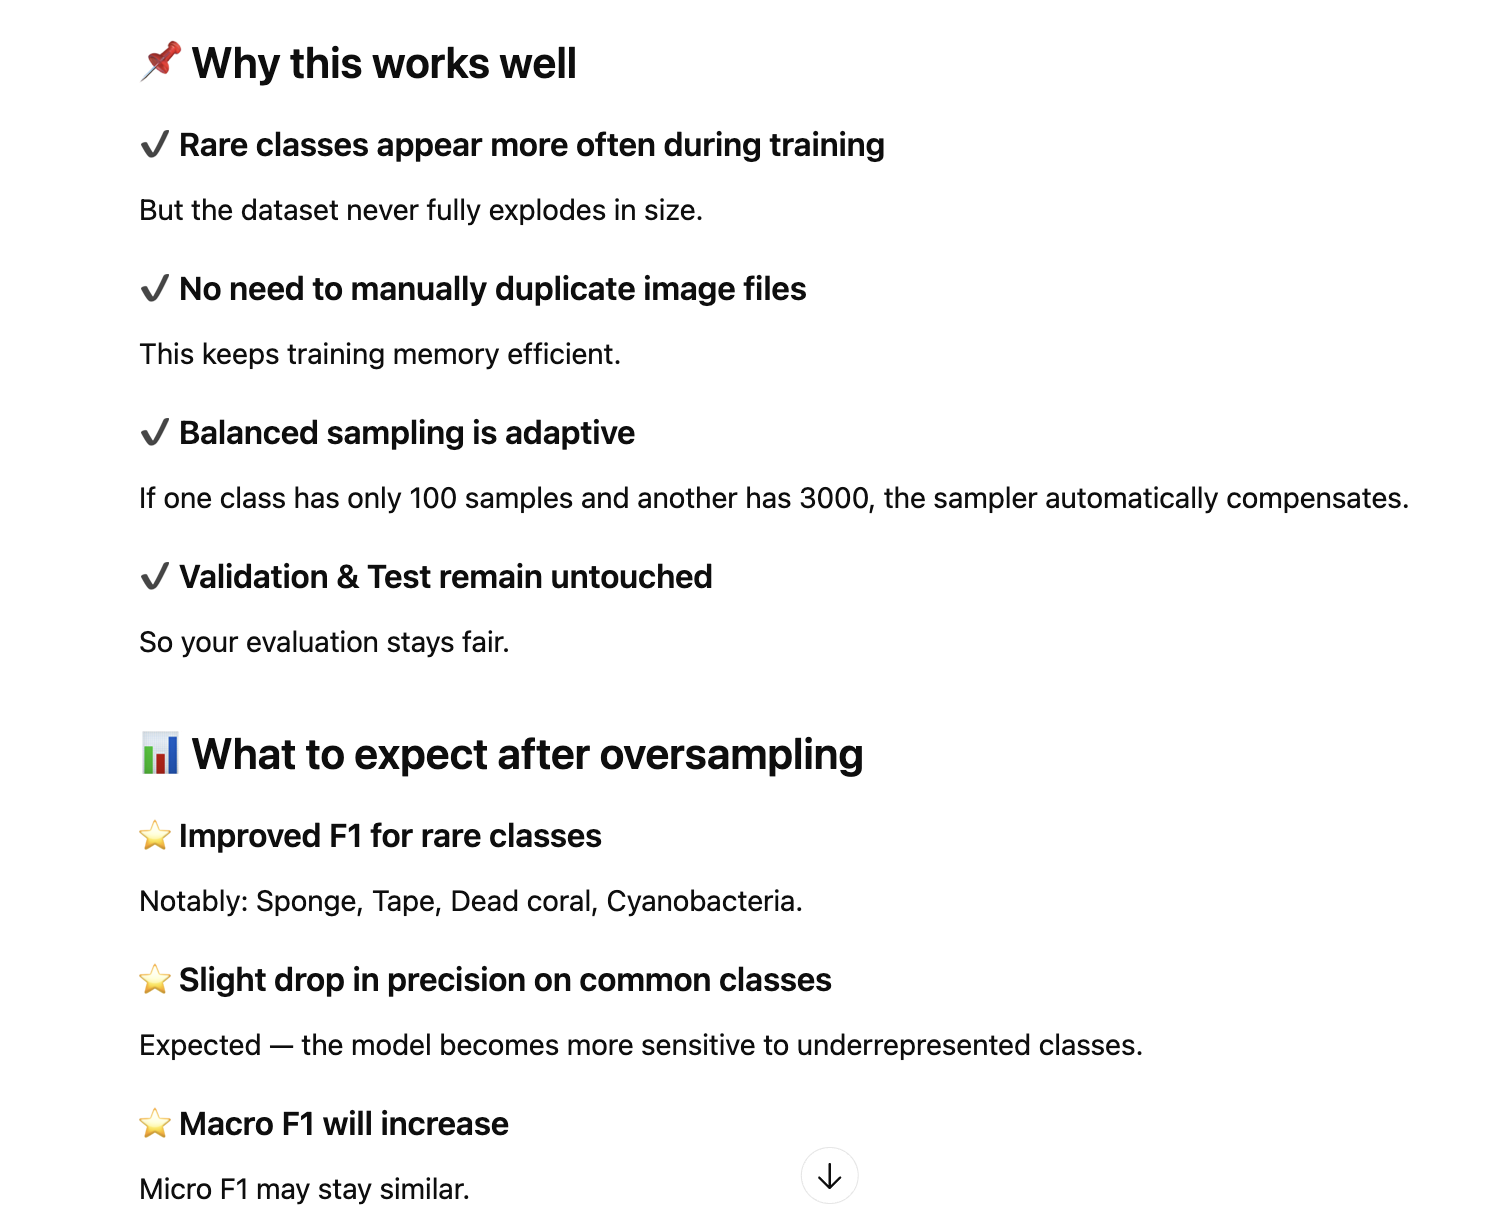

**PATCH_SIZE is simply: the image resize target before feeding into EfficientNet.**

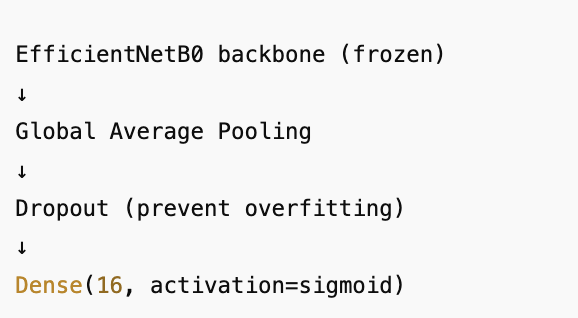

Why BCE is used in multi-label tasks

Because in multi-label classification:

Each class is independent

Each class is a binary yes/no question

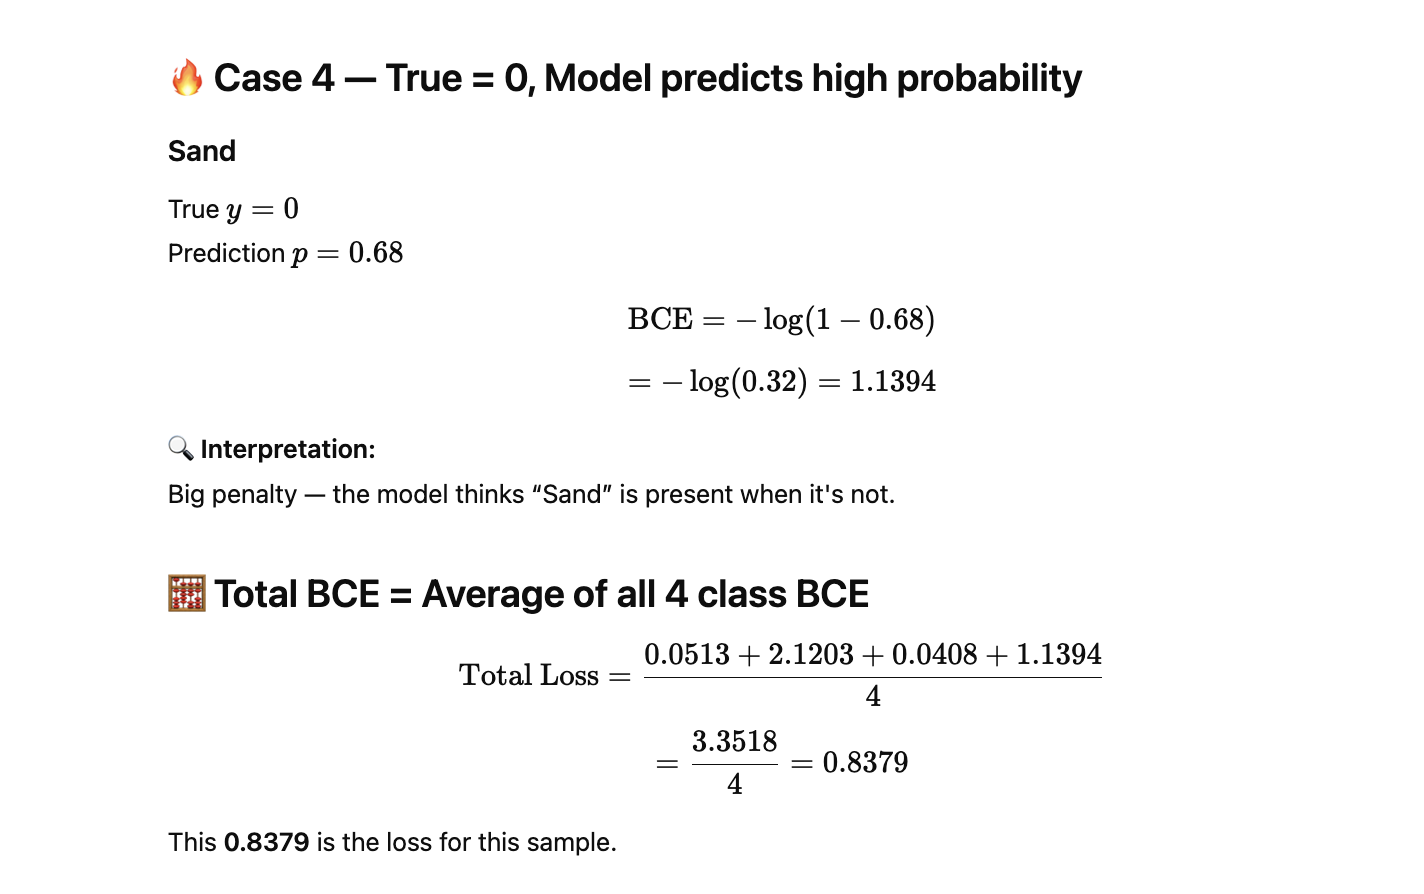

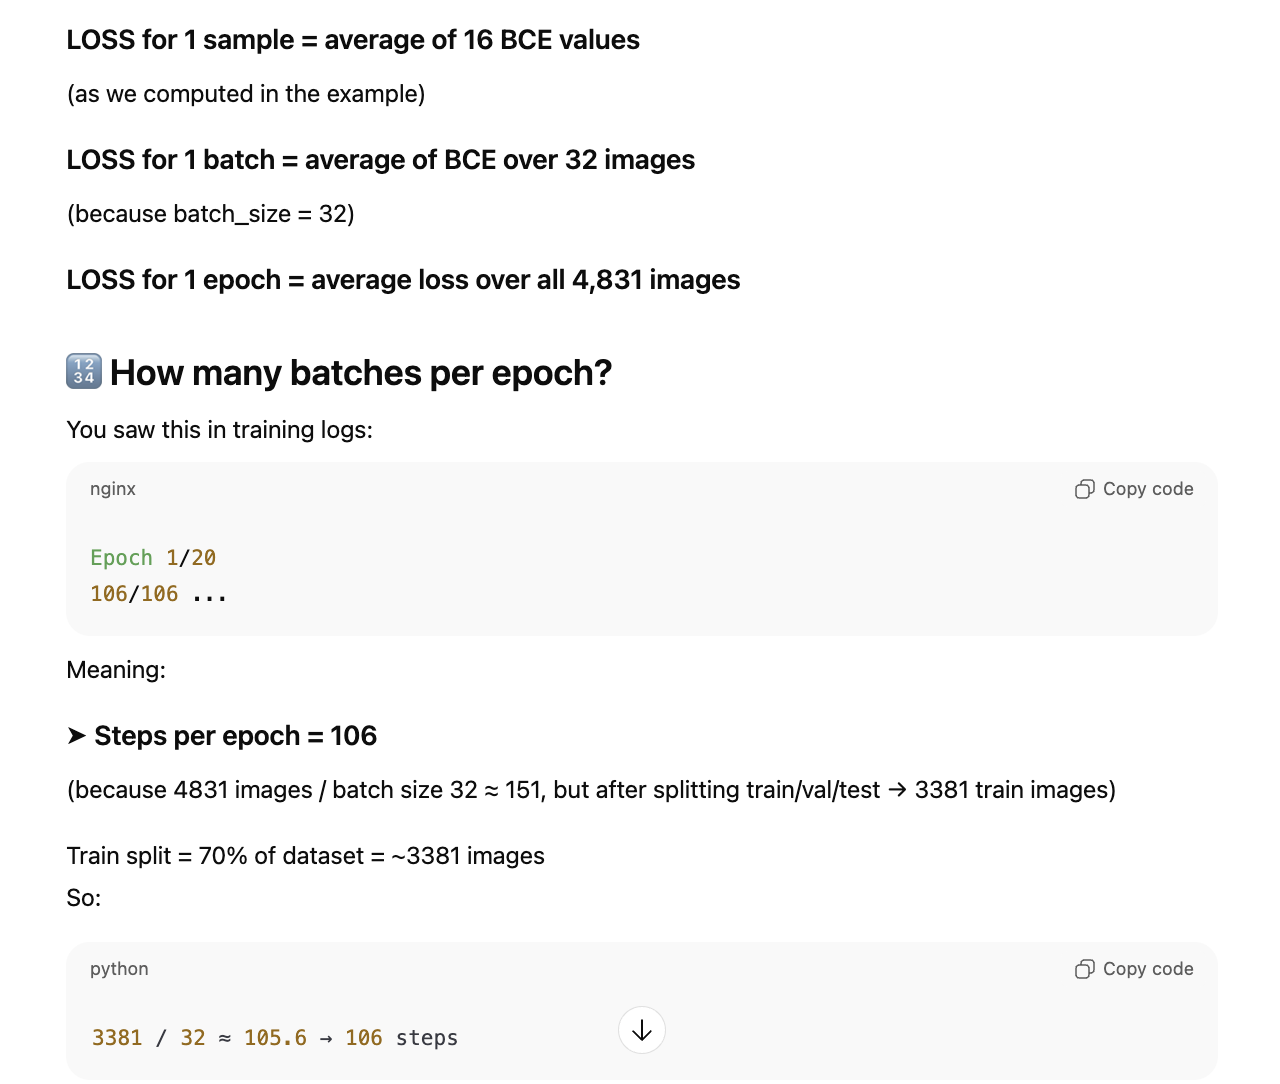

In [7]:
# =====================================================================
# 9. TRAIN STAGE 1
# =====================================================================

print("\n===== TRAINING STAGE 1 (Frozen EfficientNet) =====\n")

hist1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    callbacks=[check1, early],
    verbose=1
)


model = tf.keras.models.load_model(stage1_ckpt)
print("Loaded best Stage 1 checkpoint.\n")


===== TRAINING STAGE 1 (Frozen EfficientNet) =====

Epoch 1/20


 3/78 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - AUC: 0.4954 - loss: 0.6660    

 5/78 ━━━━━━━━━━━━━━━━━━━━ 59s 819ms/step - AUC: 0.5016 - loss: 0.6542

 9/78 ━━━━━━━━━━━━━━━━━━━━ 1:37 1s/step - AUC: 0.5118 - loss: 0.6343

13/78 ━━━━━━━━━━━━━━━━━━━━ 1:43 2s/step - AUC: 0.5219 - loss: 0.6184

...

78/78 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - AUC: 0.8791 - loss: 0.3541 - val_AUC: 0.8410 - val_loss: 0.3525
Epoch 20/20
 5/78 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - AUC: 0.8775 - loss: 0.3450

46/78 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - AUC: 0.8679 - loss: 0.3621

52/78 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - AUC: 0.8679 - loss: 0.3624

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - AUC: 0.8678 - loss: 0.3628

78/78 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - AUC: 0.8678 - loss: 0.3628 - val_AUC: 0.8431 - val_loss: 0.3550
Loaded best Stage 1 checkpoint.



In [8]:
model = tf.keras.models.load_model(stage1_ckpt)
print("Loaded best Stage 1 checkpoint.\n")


Loaded best Stage 1 checkpoint.



In [9]:

## ============================================================
# 8. TRAIN — STAGE 2 (Fine-Tuning EfficientNet)
# ============================================================

# 1) Load best Stage 1 weights
print("\nLoading best Stage 1 checkpoint...")
model = tf.keras.models.load_model(stage1_ckpt)

# 2) Freeze everything first (safe reset)
for layer in base.layers:
    layer.trainable = False

# 3) Unfreeze top 100 layers
for layer in base.layers[-100:]:
    layer.trainable = True

# 4) Recompile with lower LR and multi-label AUC
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="AUC", multi_label=True)]
)

print("\n===== TRAINING STAGE 2 (Fine-tuning) =====\n")

# 5) Train Stage 2
hist2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    callbacks=[check2, early],   # early stopping + best checkpoint
    verbose=1
)

# 6) Load best Stage 2 model
model = tf.keras.models.load_model(stage2_ckpt)
print("\nLoaded best Stage 2 checkpoint.\n")





Loading best Stage 1 checkpoint...

===== TRAINING STAGE 2 (Fine-tuning) =====

Epoch 1/15


 6/78 ━━━━━━━━━━━━━━━━━━━━ 1:50 2s/step - AUC: 0.8913 - loss: 0.3398

11/78 ━━━━━━━━━━━━━━━━━━━━ 2:12 2s/step - AUC: 0.8854 - loss: 0.3457

63/78 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - AUC: 0.8778 - loss: 0.3516

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - AUC: 0.8779 - loss: 0.3515

...

59/78 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - AUC: 0.8763 - loss: 0.3464

69/78 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - AUC: 0.8766 - loss: 0.3466

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - AUC: 0.8768 - loss: 0.3469

78/78 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - AUC: 0.8768 - loss: 0.3469 - val_AUC: 0.8434 - val_loss: 0.3522



Loaded best Stage 2 checkpoint.



In [10]:
# ============================================================
# 11. EVALUATION — Multi-label metrics
# ============================================================

print("\n===== EVALUATING ON TEST SET =====\n")
from sklearn.metrics import classification_report, f1_score

pred_prob = model.predict(test_ds)
pred_bin  = (pred_prob > 0.5).astype(int)

print("\nClassification Report (threshold = 0.5)\n")
print(classification_report(y_test, pred_bin, target_names=CLASSES))

print("Micro-F1:", f1_score(y_test, pred_bin, average="micro"))
print("Macro-F1:", f1_score(y_test, pred_bin, average="macro"))


# ============================================================
# 12. PER-CLASS AUC (ROC + PR)
# ============================================================

print("\n===== PER-CLASS AUC =====\n")

for i, cname in enumerate(CLASSES):

    # ROC-AUC
    roc_auc = tf.keras.metrics.AUC(curve="ROC")
    roc_auc.update_state(y_test[:, i], pred_prob[:, i])

    # PR-AUC
    pr_auc = tf.keras.metrics.AUC(curve="PR")
    pr_auc.update_state(y_test[:, i], pred_prob[:, i])

    support = int(y_test[:, i].sum())

    print(f"{cname:20s}  ROC-AUC = {roc_auc.result():.4f} "
          f" PR-AUC = {pr_auc.result():.4f} "
          f" Support = {support}")



===== EVALUATING ON TEST SET =====



 5/69 ━━━━━━━━━━━━━━━━━━━━ 1:07 1s/step

25/69 ━━━━━━━━━━━━━━━━━━━━ 1:05 1s/step

26/69 ━━━━━━━━━━━━━━━━━━━━ 1:03 1s/step

57/69 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step

68/69 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step

69/69 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step

Classification Report (threshold = 0.5)

                          precision    recall  f1-score   support

              Macroalgae       0.41      0.91      0.57       885
                  Rubble       0.47      0.79      0.59       841
Crustose coralline algae       0.82      0.62      0.71      1433
          Bare substrate       0.63      0.29      0.40      1265
                    Sand       0.64      0.69      0.66       816
              Turf algae       0.54      0.16      0.24      1328
                 Porites       0.54      0.46      0.49       590
              Hard coral       0.25      0.52      0.33       334
              Soft coral       0.56      0.22      0.32       870
                Acropora       0.76      0.45      0.57       720
                    Tape       0.11      0.01      0.01       136
             Pocillopora       0.62      0.03      0.06       320
              Dead coral       0.08      0.02      0.03    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Macroalgae            ROC-AUC = 0.5171  PR-AUC = 0.4049  Support = 885
Rubble                ROC-AUC = 0.6810  PR-AUC = 0.5786  Support = 841
Crustose coralline algae  ROC-AUC = 0.7317  PR-AUC = 0.8365  Support = 1433
Bare substrate        ROC-AUC = 0.5754  PR-AUC = 0.6072  Support = 1265
Sand                  ROC-AUC = 0.8168  PR-AUC = 0.7350  Support = 816
Turf algae            ROC-AUC = 0.4840  PR-AUC = 0.5827  Support = 1328
Porites               ROC-AUC = 0.7760  PR-AUC = 0.5342  Support = 590
Hard coral            ROC-AUC = 0.6857  PR-AUC = 0.2430  Support = 334
Soft coral            ROC-AUC = 0.6262  PR-AUC = 0.4871  Support = 870
Acropora              ROC-AUC = 0.8052  PR-AUC = 0.7070  Support = 720
Tape                  ROC-AUC = 0.5691  PR-AUC = 0.0745  Support = 136
Pocillopora           ROC-AUC = 0.7399  PR-AUC = 0.3448  Support = 320
Dead coral            ROC-AUC = 0.5424  PR-AUC = 0.0971  Support = 196
Montipora             ROC-AUC = 0.6679  PR-AUC = 0.1480  Support = 185

In [11]:
# ============================================================
# 13. PER-CLASS OPTIMAL THRESHOLD SEARCH
# ============================================================

print("\n===== PER-CLASS OPTIMAL THRESHOLD =====\n")

import numpy as np
from sklearn.metrics import f1_score

def find_best_threshold(y_true, y_prob, n_thresholds=100):
    """Find best F1 threshold for one class."""
    thresholds = np.linspace(0.0, 1.0, n_thresholds)
    best_t, best_f1 = 0.5, 0.0

    # Handle case where class has ZERO positive samples
    if y_true.sum() == 0:
        return None, None

    for t in thresholds:
        pred = (y_prob > t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    return best_t, best_f1


# Pretty print aligned output
print(f"{'Class':25s} {'Support':>8s} {'Best_t':>8s} {'Best_F1':>10s}")
print("-" * 55)

class_support = y_test.sum(axis=0)

for i, cname in enumerate(CLASSES):
    support = int(class_support[i])
    best_t, best_f1 = find_best_threshold(y_test[:, i], pred_prob[:, i])

    if best_t is None:
        print(f"{cname:25s} {support:8d}   n/a       n/a    (no positives)")
        continue

    print(f"{cname:25s} {support:8d}   {best_t:6.2f}   {best_f1:8.3f}")



===== PER-CLASS OPTIMAL THRESHOLD =====

Class                      Support   Best_t    Best_F1
-------------------------------------------------------
Macroalgae                     885     0.06      0.577
Rubble                         841     0.54      0.592
Crustose coralline algae      1433     0.11      0.800
Bare substrate                1265     0.08      0.740
Sand                           816     0.38      0.686
Turf algae                    1328     0.00      0.756
Porites                        590     0.26      0.565
Hard coral                     334     0.39      0.357
Soft coral                     870     0.12      0.593
Acropora                       720     0.21      0.631
Tape                           136     0.07      0.139
Pocillopora                    320     0.13      0.399
Dead coral                     196     0.08      0.177
Montipora                      185     0.15      0.223
Cyanobacteria                  138     0.16      0.199
Sponge                

In [12]:
# ============================================================
# 14    Multi-Label Evaluation with Optimal Thresholds
# ============================================================

import numpy as np
from sklearn.metrics import classification_report, f1_score

# ------------------------------------------------------------
# 1. You already computed these earlier (best thresholds)
#    IMPORTANT: order must match CLASSES exactly.
# ------------------------------------------------------------


best_t = np.array([
    0.06,  # Macroalgae
    0.54,  # Rubble
    0.11,  # Crustose coralline algae
    0.08,  # Bare substrate
    0.38,  # Sand
    0.00,  # Turf algae
    0.26,  # Porites
    0.39,  # Hard coral
    0.12,  # Soft coral
    0.21,  # Acropora
    0.07,  # Tape
    0.13,  # Pocillopora
    0.08,  # Dead coral
    0.15,  # Montipora
    0.16,  # Cyanobacteria
    0.01   # Sponge
])

print("Loaded per-class optimal thresholds:\n")
for cname, t in zip(CLASSES, best_t):
    print(f"{cname:25s}  {t:.2f}")

model = tf.keras.models.load_model(stage2_ckpt)
print("Loaded best Stage 2 checkpoint.\n")

pred_prob = model.predict(test_ds)

# ------------------------------------------------------------
# 2. OLD threshold = 0.5 (what you used before)
# ------------------------------------------------------------

pred_bin_old = (pred_prob > 0.5).astype(int)

# ------------------------------------------------------------
# 3. NEW threshold = best_t (per class)
# ------------------------------------------------------------

pred_bin_new = (pred_prob > best_t).astype(int)

# ------------------------------------------------------------
# 4. Print reports
# ------------------------------------------------------------

print("\n=====================================================")
print("  CLASSIFICATION REPORT — OLD THRESHOLD (0.5)")
print("=====================================================\n")
print(classification_report(y_test, pred_bin_old, target_names=CLASSES))


print("\n=====================================================")
print("  CLASSIFICATION REPORT — OPTIMAL THRESHOLDS")
print("=====================================================\n")
print(classification_report(y_test, pred_bin_new, target_names=CLASSES))


# ------------------------------------------------------------
# 5. Compare Macro F1
# ------------------------------------------------------------

old_macro_f1 = f1_score(y_test, pred_bin_old, average='macro')
new_macro_f1 = f1_score(y_test, pred_bin_new, average='macro')

print("\n=====================================================")
print("                 MACRO F1 COMPARISON")
print("=====================================================")
print(f"Macro F1 (threshold = 0.5):            {old_macro_f1:.4f}")
print(f"Macro F1 (optimal per-class thresh):   {new_macro_f1:.4f}")
print("=====================================================\n")


Loaded per-class optimal thresholds:

Macroalgae                 0.06
Rubble                     0.54
Crustose coralline algae   0.11
Bare substrate             0.08
Sand                       0.38
Turf algae                 0.00
Porites                    0.26
Hard coral                 0.39
Soft coral                 0.12
Acropora                   0.21
Tape                       0.07
Pocillopora                0.13
Dead coral                 0.08
Montipora                  0.15
Cyanobacteria              0.16
Sponge                     0.01
Loaded best Stage 2 checkpoint.



 6/69 ━━━━━━━━━━━━━━━━━━━━ 1:11 1s/step

25/69 ━━━━━━━━━━━━━━━━━━━━ 1:04 1s/step

59/69 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step

68/69 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

69/69 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step

  CLASSIFICATION REPORT — OLD THRESHOLD (0.5)

                          precision    recall  f1-score   support

              Macroalgae       0.41      0.91      0.57       885
                  Rubble       0.47      0.79      0.59       841
Crustose coralline algae       0.82      0.62      0.71      1433
          Bare substrate       0.63      0.29      0.40      1265
                    Sand       0.64      0.69      0.66       816
              Turf algae       0.54      0.16      0.24      1328
                 Porites       0.54      0.46      0.49       590
              Hard coral       0.25      0.52      0.33       334
              Soft coral       0.56      0.22      0.32       870
                Acropora       0.76      0.45      0.57       720
                    Tape       0.11      0.01      0.01       136
             Pocillopora       0.62      0.03      0.06       320
              Dead coral       0.08      0.02      0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**evaluate multi-label models using per-class optimal thresholds.**

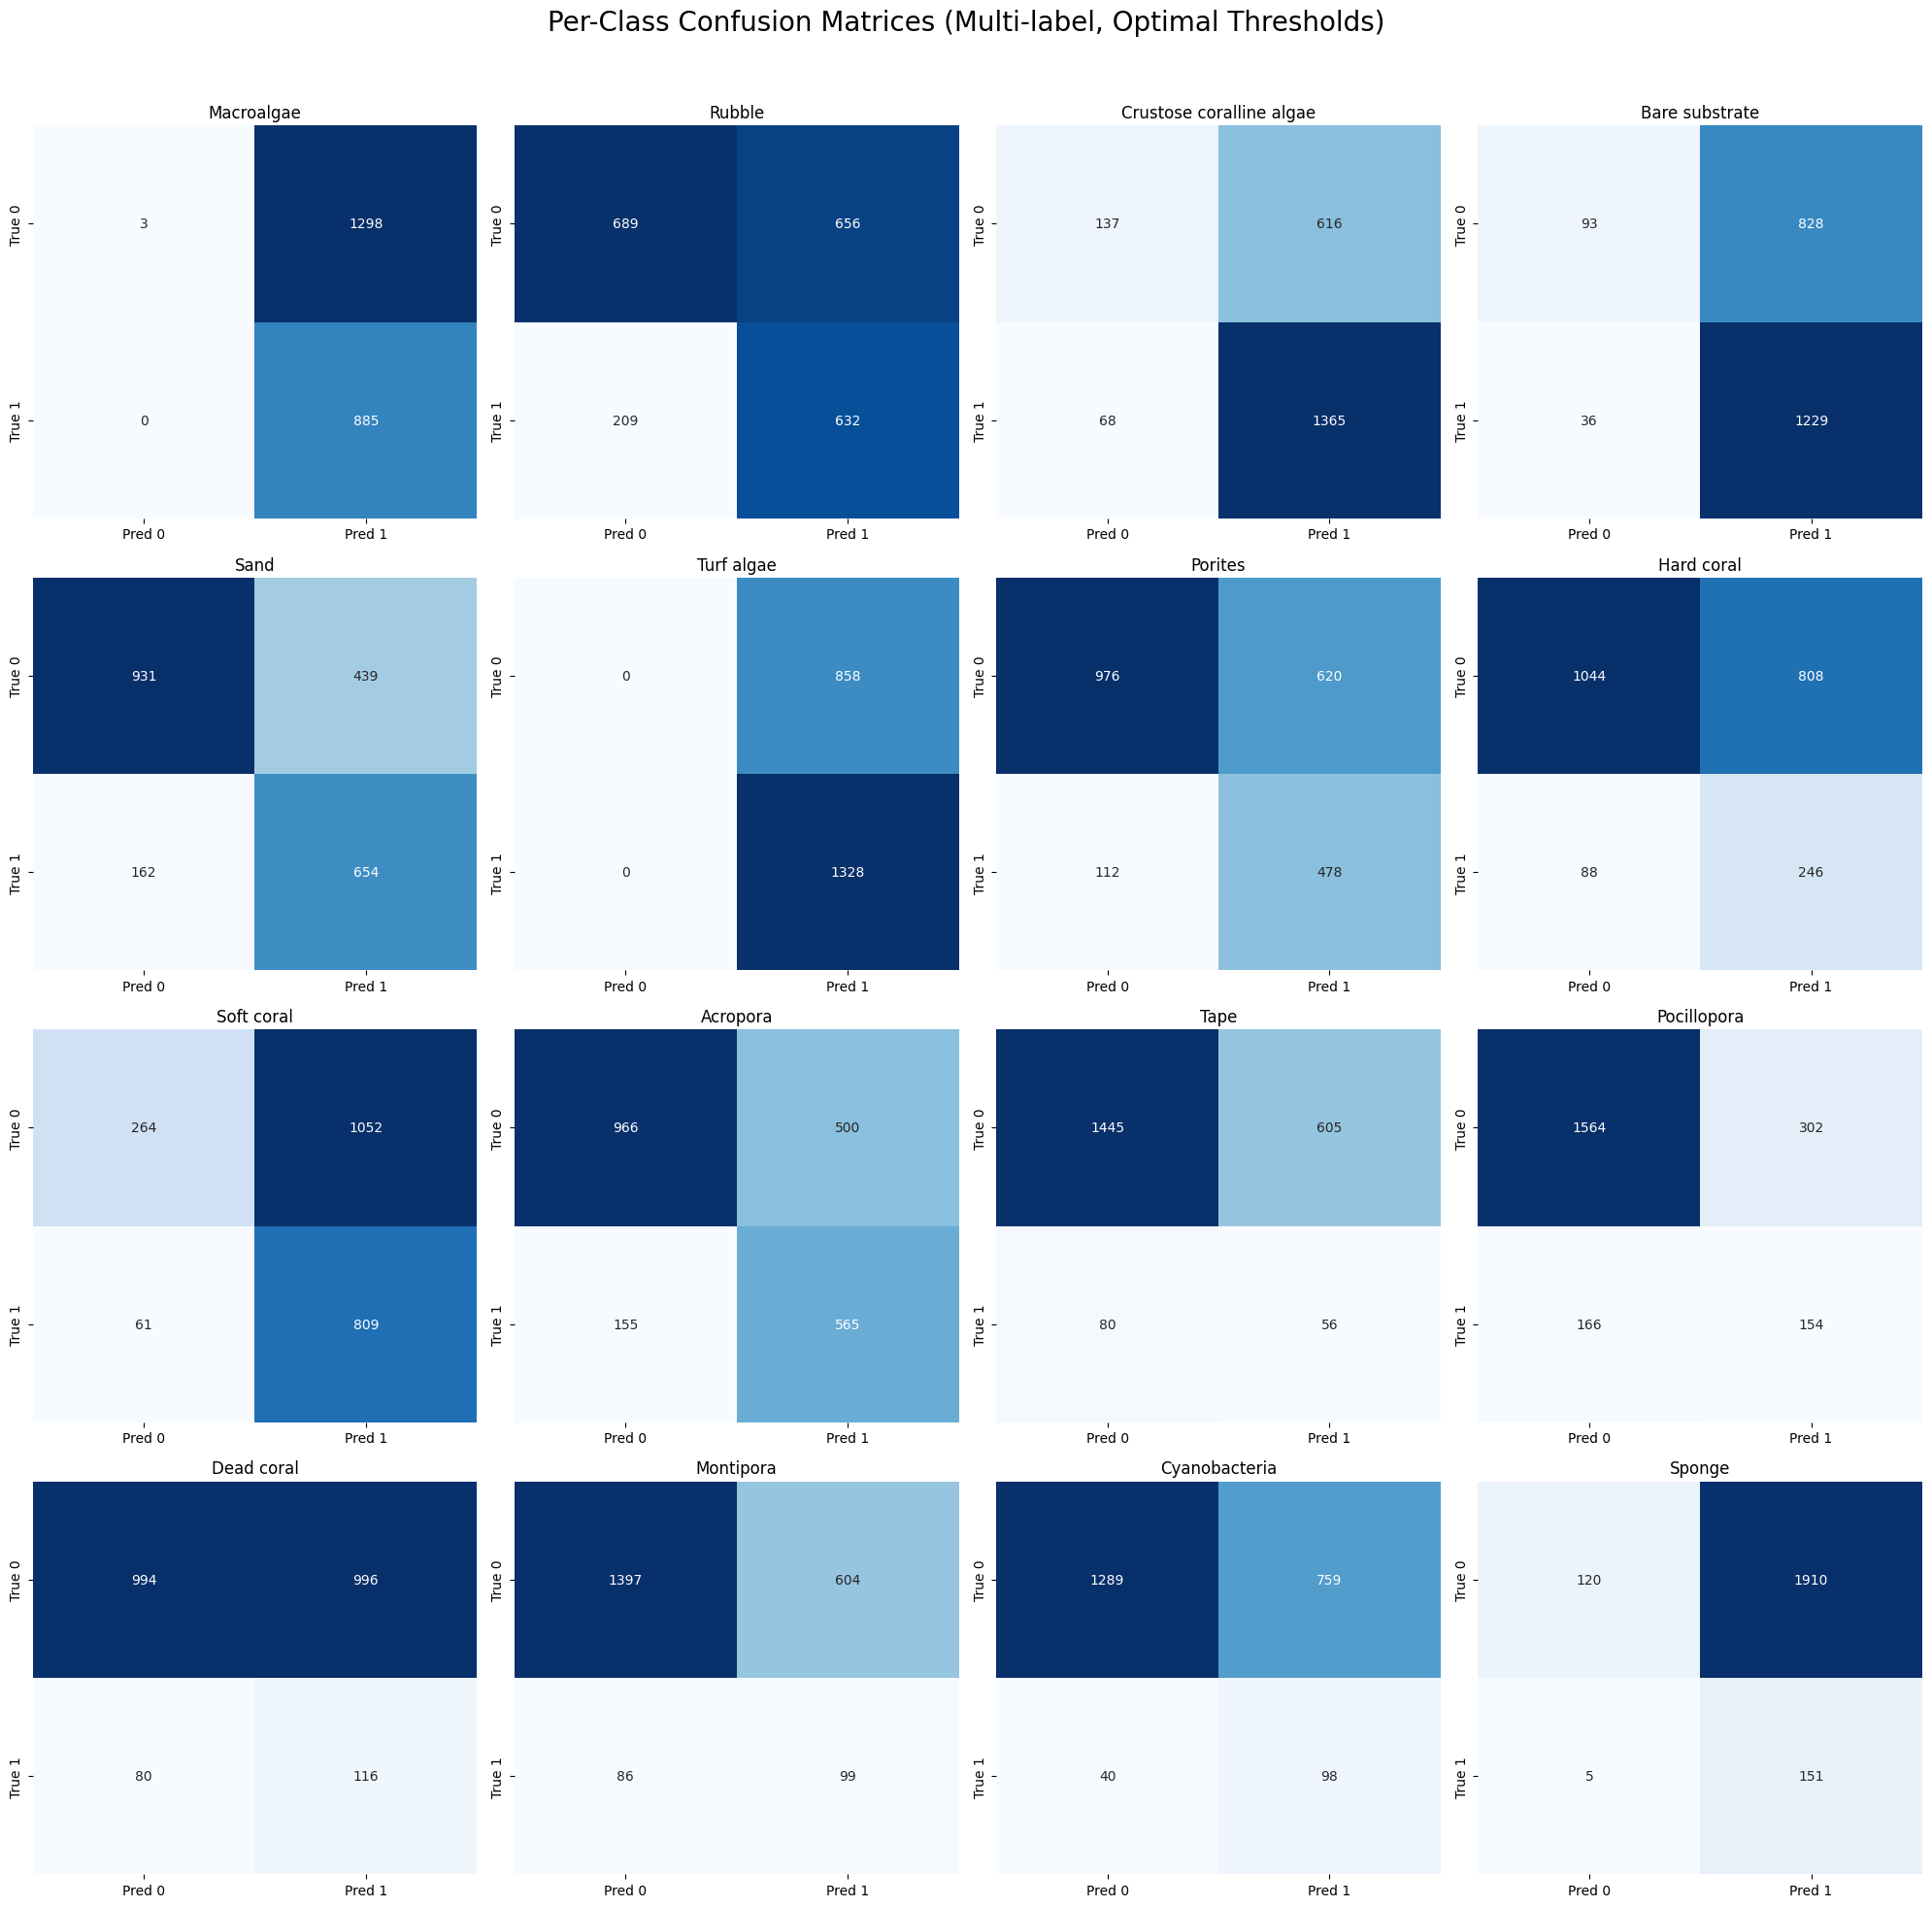

In [13]:
# ============================================================
#15  CONFUSION MATRIX PLOTS — PER-CLASS (Multi-Label)
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

num_classes = len(CLASSES)

plt.figure(figsize=(20, 20))
plt.suptitle("Per-Class Confusion Matrices (Multi-label, Optimal Thresholds)", fontsize=20)

for i, cname in enumerate(CLASSES):
    # compute 2×2 confusion matrix for this class
    cm = confusion_matrix(y_test[:, i], pred_bin_new[:, i])

    # Plot each confusion matrix
    plt.subplot(4, 4, i + 1)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["True 0", "True 1"])

    plt.title(cname, fontsize=12)
    plt.xlabel("")
    plt.ylabel("")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


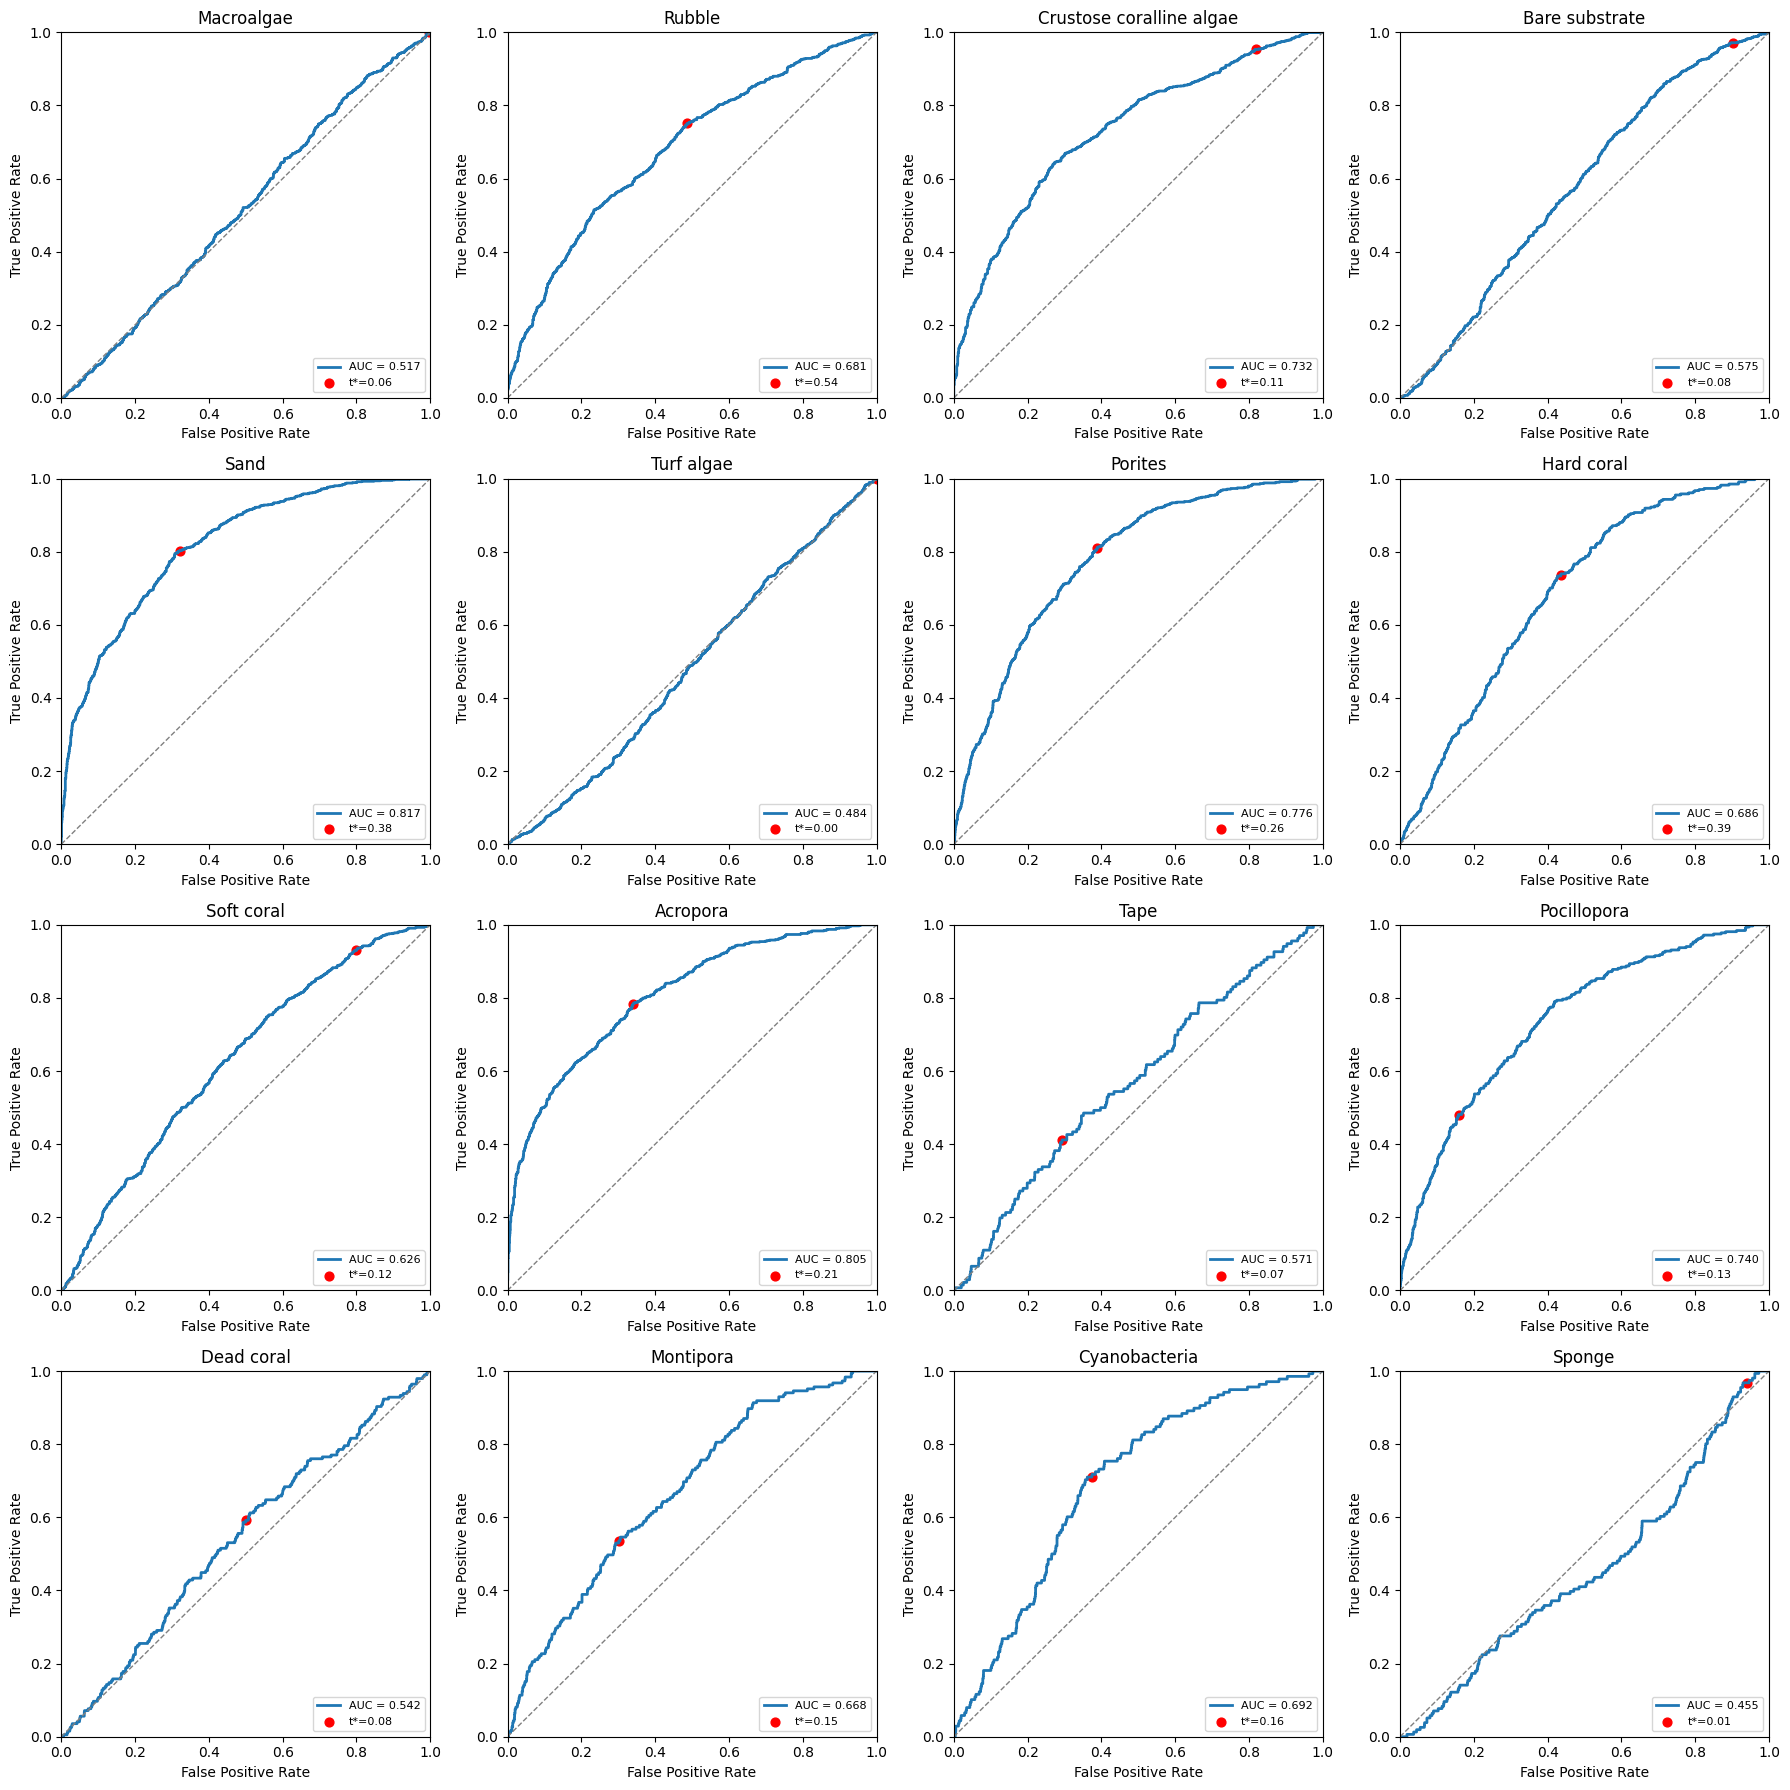

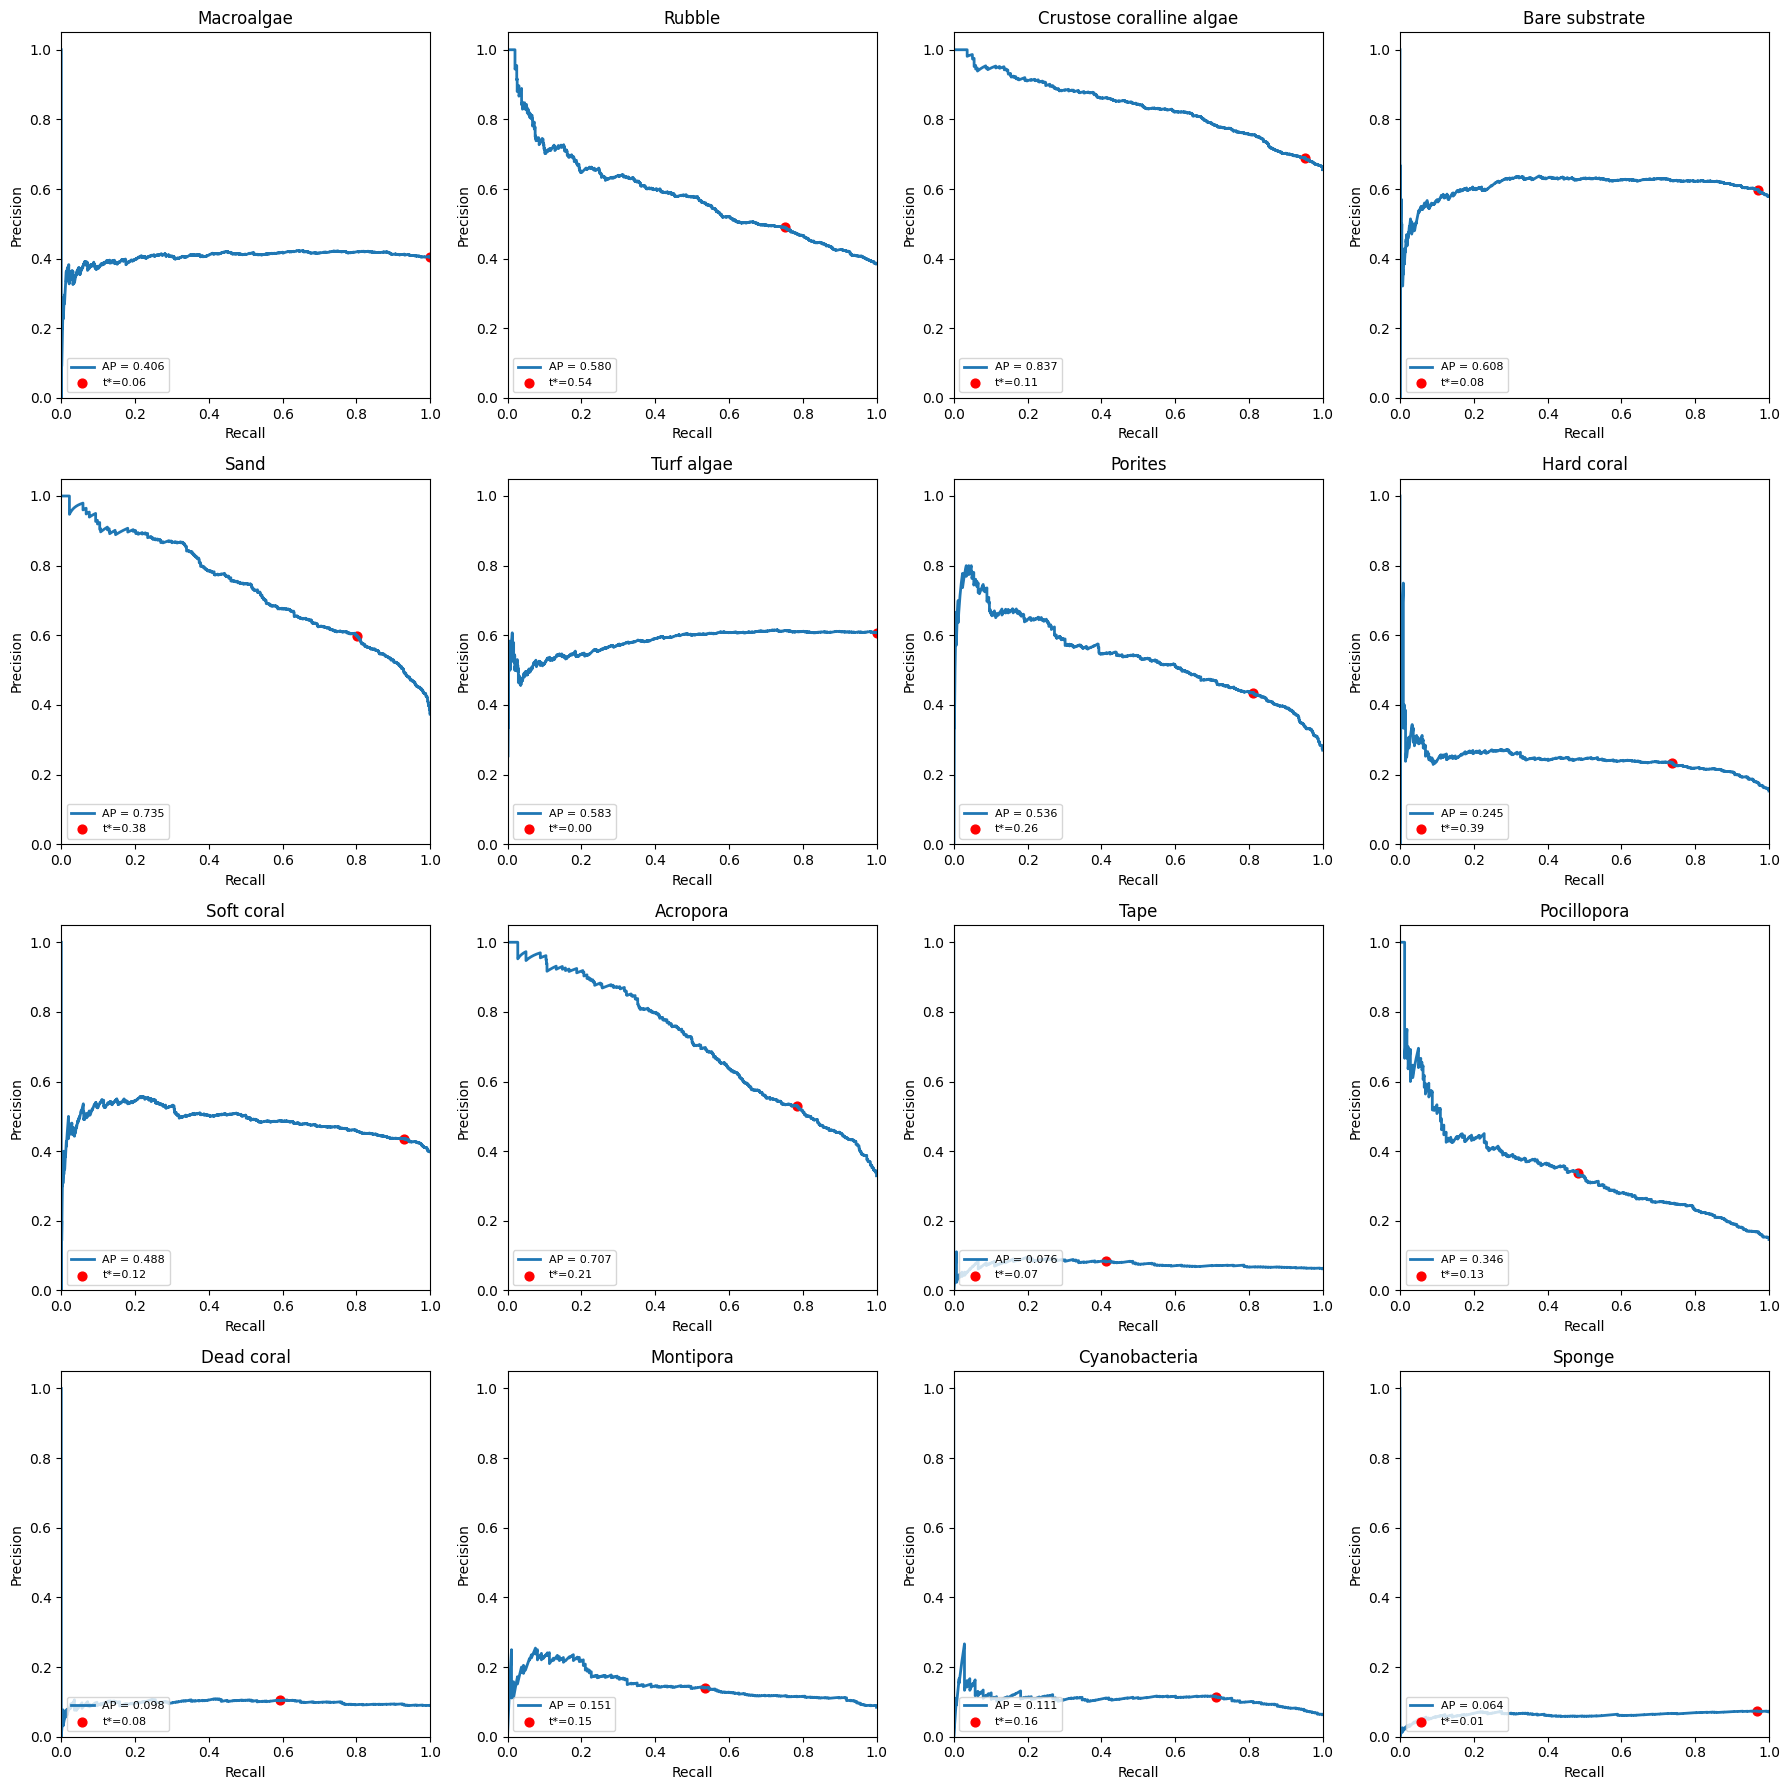

array([0.06, 0.54, 0.11, 0.08, 0.38, 0.  , 0.26, 0.39, 0.12, 0.21, 0.07,
       0.13, 0.08, 0.15, 0.16, 0.01])

In [14]:
# ============================================================
# 16 ROC & PR CURVES WITH OPTIMAL THRESHOLD MARKERS
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np

num_classes = len(CLASSES)
cols = 4
rows = int(np.ceil(num_classes / cols))

# ------------------------------------------------------------
# 1. ROC CURVES WITH THRESHOLD MARKERS
# ------------------------------------------------------------

fig, axes = plt.subplots(rows, cols, figsize=(18, 18))
axes = axes.flatten()

for i, cname in enumerate(CLASSES):
    ax = axes[i]

    y_true = y_test[:, i]
    y_prob = pred_prob[:, i]
    t_opt = best_t[i]

    if y_true.sum() == 0:
        ax.text(0.5, 0.5, "No Positives", ha="center", va="center", fontsize=10)
        ax.set_title(cname)
        ax.axis("off")
        continue

    # Compute ROC curve
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    # Find closest threshold index on ROC curve
    idx = np.argmin(np.abs(roc_thresholds - t_opt))

    # Draw ROC curve
    ax.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1)

    # Add threshold marker
    ax.scatter(fpr[idx], tpr[idx], color='red', s=40,
               label=f"t*={t_opt:.2f}")

    ax.set_title(cname, fontsize=12)
    ax.set_xlim([0,1])
    ax.set_ylim([0,1])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right", fontsize=8)

# Clean unused axes
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()



# ------------------------------------------------------------
# 2. PR CURVES WITH THRESHOLD MARKERS
# ------------------------------------------------------------

fig, axes = plt.subplots(rows, cols, figsize=(18, 18))
axes = axes.flatten()

for i, cname in enumerate(CLASSES):
    ax = axes[i]

    y_true = y_test[:, i]
    y_prob = pred_prob[:, i]
    t_opt = best_t[i]

    if y_true.sum() == 0:
        ax.text(0.5, 0.5, "No Positives", ha="center", va="center", fontsize=10)
        ax.set_title(cname)
        ax.axis("off")
        continue

    # Compute PR curve
    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    # pr_thresholds has length N-1; match threshold range
    # find index with closest threshold
    # for t == 0 or t == 1 edge cases
    if t_opt <= pr_thresholds.min():
        idx = 0
    elif t_opt >= pr_thresholds.max():
        idx = len(pr_thresholds) - 1
    else:
        idx = np.argmin(np.abs(pr_thresholds - t_opt))

    # Draw PR curve
    ax.plot(recall, precision, lw=2, label=f"AP = {pr_auc:.3f}")

    # Add threshold marker
    ax.scatter(recall[idx], precision[idx], color='red', s=40,
               label=f"t*={t_opt:.2f}")

    ax.set_title(cname, fontsize=12)
    ax.set_xlim([0,1])
    ax.set_ylim([0,1.05])
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(loc="lower left", fontsize=8)

# Clean unused axes
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

best_t

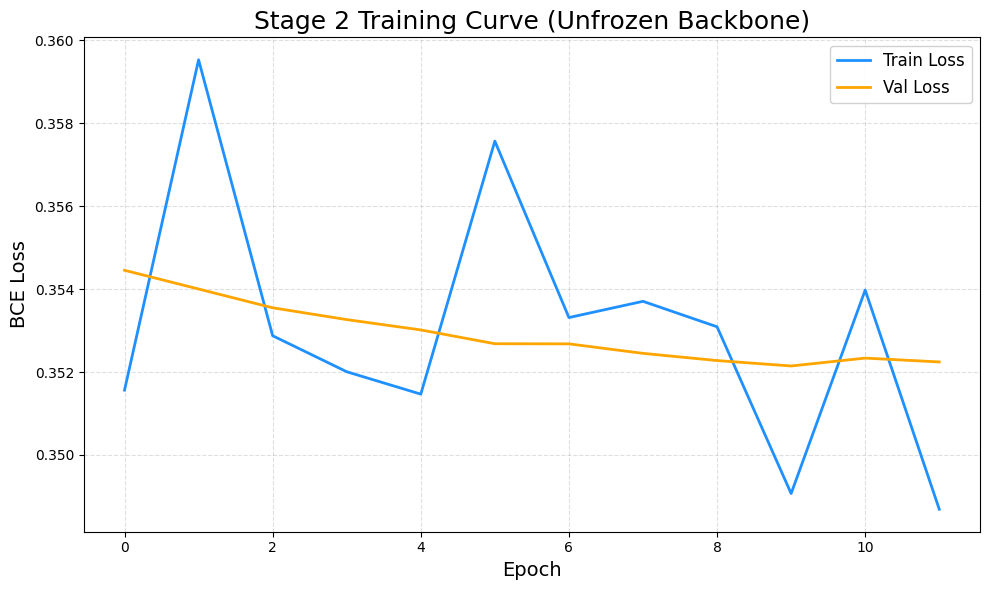

In [15]:
#Stage 2 Training Curve Plot
import matplotlib.pyplot as plt

# Extract loss curves
train_loss = hist2.history["loss"]
val_loss   = hist2.history["val_loss"]

epochs = range(len(train_loss))

plt.figure(figsize=(10, 6))

# Plot curves
plt.plot(epochs, train_loss, label="Train Loss", color='dodgerblue', linewidth=2)
plt.plot(epochs, val_loss,   label="Val Loss",   color='orange', linewidth=2)

# Title & labels
plt.title("Stage 2 Training Curve (Unfrozen Backbone)", fontsize=18)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("BCE Loss", fontsize=14)

# Grid
plt.grid(True, linestyle="--", alpha=0.4)

# Legend
plt.legend(fontsize=12, framealpha=0.9)

# Tweak spacing
plt.tight_layout()

# Show the figure
plt.show()
